# Tarea 8 — Segmentación de clientes: K-Means y clustering jerárquico
**Lead University · Minería de Datos · Tarea 8**

Segmentación de `Customers.csv` (Kaggle: *Customer Segmentation*): 2 000 clientes de un centro
comercial descritos por cinco variables numéricas — `Age`, `Annual Income ($)`,
`Spending Score (1-100)`, `Work Experience` y `Family Size`.

**Objetivo:** determinar el número óptimo de clusters con el Codo de Jambú, aplicar K-Means y
clustering jerárquico aglomerativo, y comparar ambas particiones sobre el plano del PCA.

---
## a) Selección y exploración de datos

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from scripts import ClusteringJerarquico, KMeansAnalysis

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

In [2]:
datos = pd.read_csv("datos/Customers.csv")
print("Dimensiones:", datos.shape)
datos.head()

Dimensiones: (2000, 8)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [4]:
variables = ["Age", "Annual Income ($)", "Spending Score (1-100)", "Work Experience", "Family Size"]
datos[variables].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,48.96,28.43,0.0,25.0,48.0,73.00,99.0
Annual Income ($),2000.0,110731.82,45739.54,0.0,74572.0,110045.0,149092.75,189974.0
Spending Score (1-100),2000.0,50.96,27.93,0.0,28.0,50.0,75.00,100.0
Work Experience,2000.0,4.10,3.92,0.0,1.0,3.0,7.00,17.0
Family Size,2000.0,3.77,1.97,1.0,2.0,4.0,5.00,9.0


**Contexto del dataset:**
El archivo trae 2 000 clientes y 8 columnas, de las cuales cinco son numéricas y sirven para el
análisis de distancia. Los estadísticos descriptivos muestran el problema que obliga a estandarizar:
`Annual Income ($)` se mueve en el orden de las decenas de miles mientras que `Family Size` va de 1 a 9,
de modo que una distancia euclídea sin escalar quedaría determinada casi por completo por el ingreso.
Las medias son muy centradas (edad media de 49 años, puntaje de gasto de 51), lo que anticipa un
dataset uniforme sin grupos naturales muy separados.

In [5]:
# Diagnóstico de calidad: nulos y ceros imposibles
print("Valores nulos por columna:")
print(datos.isna().sum())
print("\nCeros en variables numéricas (posibles nulos codificados como 0):")
print((datos[variables] == 0).sum())

Valores nulos por columna:
CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

Ceros en variables numéricas (posibles nulos codificados como 0):
Age                        24
Annual Income ($)           2
Spending Score (1-100)      2
Work Experience           431
Family Size                 0
dtype: int64


**Problemas de calidad detectados:**
`Profession` tiene 35 nulos (1,75 % de los registros); como es cualitativa y no entra en el clustering,
se imputa con la etiqueta `"Desconocida"`. Más relevante es que `Age` tiene 24 ceros y
`Annual Income ($)` tiene 2: una edad de 0 años y un ingreso anual de 0 dólares no son valores
plausibles en un cliente de centro comercial, así que se tratan como nulos codificados como cero, se
convierten a `NaN` y se imputan con la mediana. En cambio los 431 ceros de `Work Experience` y los 2 de
`Spending Score` sí son válidos —significan una persona sin experiencia laboral y un puntaje mínimo de
gasto— y se conservan sin tocar.

---
## b) Preprocesamiento

In [6]:
df = datos.copy()

# Nulos cualitativos: no afectan el clustering, solo la caracterización posterior
df["Profession"] = df["Profession"].fillna("Desconocida")

# Ceros imposibles → NaN → mediana
df.loc[df["Age"] == 0, "Age"] = np.nan
df.loc[df["Annual Income ($)"] == 0, "Annual Income ($)"] = np.nan
print("Nulos a imputar:")
print(df[variables].isna().sum()[lambda s: s > 0])

medianas = df[variables].median()
df[variables] = df[variables].fillna(medianas)
print("\nMedianas usadas para imputar:")
print(medianas.round(1))
print("\nNulos restantes:", int(df[variables].isna().sum().sum()))

Nulos a imputar:
Age                  24
Annual Income ($)     2
dtype: int64

Medianas usadas para imputar:
Age                           49.0
Annual Income ($)         110252.0
Spending Score (1-100)        50.0
Work Experience                3.0
Family Size                    4.0
dtype: float64

Nulos restantes: 0


In [7]:
# Detección de atípicos con la regla del rango intercuartílico (1.5 · IQR)
resumen_atipicos = []
for col in variables:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < lo) | (df[col] > hi)).sum())
    resumen_atipicos.append({"variable": col, "limite_inf": round(lo, 1), "limite_sup": round(hi, 1), "n_atipicos": n_out})

pd.DataFrame(resumen_atipicos)

,variable,limite_inf,limite_sup,n_atipicos
0,Age,-44.5,143.5,0
1,Annual Income ($),-36666.6,260548.4,0
2,Spending Score (1-100),-42.5,145.5,0
3,Work Experience,-8.0,16.0,5
4,Family Size,-2.5,9.5,0


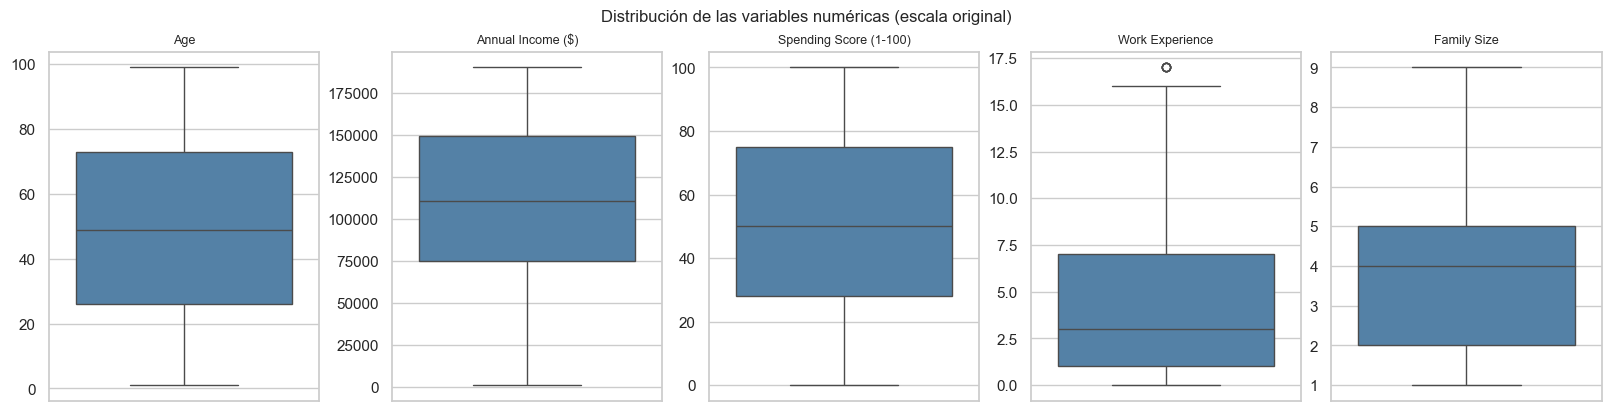

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4), constrained_layout=True)
for ax, col in zip(axes, variables):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
fig.suptitle("Distribución de las variables numéricas (escala original)", fontsize=12)
plt.show()

**Tratamiento de atípicos:**
La regla del 1,5 · IQR solo marca 5 registros, todos en `Work Experience` (clientes con más de 16 años
de experiencia). Las otras cuatro variables no tienen ni un atípico: los límites calculados quedan muy
por fuera del rango real de los datos —para `Age` el límite superior es de 143,5 años— y los boxplots lo
confirman con cajas anchas y bigotes que cubren casi todo el rango. No se eliminan ni recortan esos
cinco valores, porque 17 años de experiencia laboral es un dato perfectamente real y con 2 000
observaciones cinco puntos no pueden arrastrar un centroide. La ausencia de atípicos y lo uniforme de
las distribuciones es la primera señal de que este dataset no tiene grupos naturales bien separados.

In [9]:
# Estandarización obligatoria (z-score): media 0, desviación 1
escalador = StandardScaler()
X = escalador.fit_transform(df[variables])
X_scaled = pd.DataFrame(X, columns=variables, index=df["CustomerID"])
X_scaled.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,-0.0,1.0,-1.740,-0.844,-0.020,0.840,1.772
Annual Income ($),2000.0,0.0,1.0,-2.409,-0.791,-0.013,0.839,1.736
Spending Score (1-100),2000.0,0.0,1.0,-1.825,-0.822,-0.034,0.861,1.756
Work Experience,2000.0,-0.0,1.0,-1.046,-0.791,-0.281,0.739,3.289
Family Size,2000.0,0.0,1.0,-1.405,-0.898,0.117,0.625,2.655


**Efecto de la estandarización:**
Después del z-score todas las variables tienen media 0 y desviación 1, así que un salto de una
desviación en `Family Size` pesa lo mismo que un salto de una desviación en `Annual Income ($)`, que es
exactamente la condición exigida para que las escalas no sesguen las distancias. Los rangos
estandarizados van de −2,41 (el ingreso más bajo) a +3,29 (`Work Experience`), única variable con una
cola apreciable a la derecha por efecto de los cinco clientes más veteranos. Ninguna variable domina el
espacio de distancias por razón de su escala.

---
## c) Determinación del número óptimo de clusters (K)

In [10]:
km = KMeansAnalysis(X_scaled)

(2000, 5)


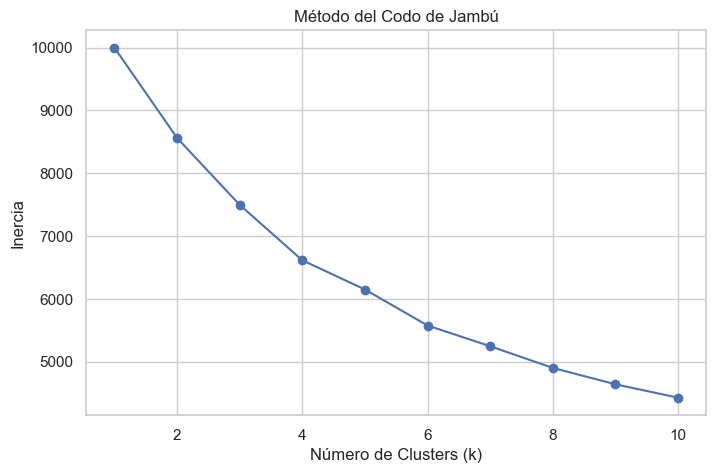

,k,inercia,reduccion_%_vs_k-1
0,2,8563.3,14.4
1,3,7498.0,12.4
2,4,6615.8,11.8
3,5,6150.6,7.0
4,6,5577.5,9.3
5,7,5247.8,5.9
6,8,4902.6,6.6
7,9,4641.8,5.3
8,10,4428.9,4.6


In [11]:
inercias = km.codo_jambu(max_k=10)

caidas = [(inercias[i - 1] - inercias[i]) / inercias[i - 1] * 100 for i in range(1, len(inercias))]
pd.DataFrame({
    "k": range(2, 11),
    "inercia": np.round(inercias[1:], 1),
    "reduccion_%_vs_k-1": np.round(caidas, 1),
})

**Método del Codo de Jambú:**
La curva de inercia desciende de forma continua, pero la tabla de reducciones porcentuales revela un
quiebre nítido en k = 4: hasta ese valor cada cluster adicional aporta más del 11 % de reducción de
inercia (14,4 % en k=2, 12,4 % en k=3 y 11,8 % en k=4) y en k=5 la ganancia marginal se corta casi a la
mitad, hasta el 7,0 %. De k=6 a k=10 oscila entre 4,6 % y 9,3 % sin recuperar nunca el nivel previo. Ese
paso de 11,8 % a 7,0 % es la mayor pérdida de rendimiento marginal de toda la serie y fija el codo en
K = 4. A partir de ahí los clusters adicionales solo fragmentan el mismo espacio sin descubrir
estructura nueva, que es el comportamiento esperable en un dataset de distribuciones uniformes.

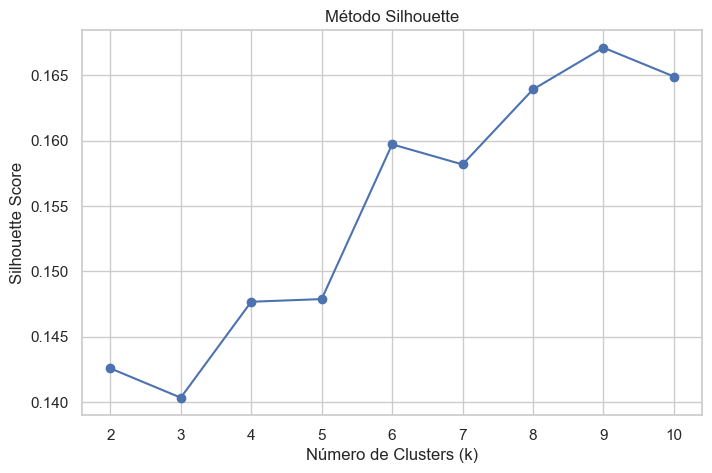

,k,silhouette
0,2,0.1426
1,3,0.1403
2,4,0.1477
3,5,0.1479
4,6,0.1597
5,7,0.1582
6,8,0.1639
7,9,0.1671
8,10,0.1649


In [12]:
sil_df = km.silhouette_kmeans(max_k=10)
sil_df.round(4)

**Método de la Silueta:**
Es el hallazgo más importante del análisis y conviene decirlo con claridad: la silueta es muy baja en
todo el rango, entre 0,140 y 0,167, cuando valores por debajo de 0,25 indican que no existe estructura
de clusters sustancial. Además la curva es prácticamente plana y creciente hacia el final —el máximo
técnico está en k=9 con 0,1671, apenas 0,025 por encima del valor en k=2— y que la silueta suba al
aumentar k, en lugar de tener un pico interior, es la firma de una nube sin grupos: partirla más fino
siempre mejora marginalmente la compacidad porque no hay fronteras naturales que respetar. Con este
comportamiento la silueta no permite determinar un K óptimo.

Se toma entonces K = 4 por el codo de Jambú, que sí muestra un quiebre claro, y por interpretabilidad de
negocio, asumiendo explícitamente que los grupos resultantes son una partición útil impuesta sobre un
continuo y no clusters naturales descubiertos en los datos. Cualquier conclusión comercial debe leerse
con esa reserva.

In [13]:
K = 4
print(f"K seleccionado = {K} (criterio: codo de Jambú + interpretabilidad de negocio)")
print(f"Silueta en K={K}: {sil_df.loc[sil_df['k'] == K, 'silhouette'].iloc[0]:.4f}  (estructura débil)")

K seleccionado = 4 (criterio: codo de Jambú + interpretabilidad de negocio)
Silueta en K=4: 0.1477  (estructura débil)


---
## d) Aplicación de algoritmos

### K-Means con el K óptimo

In [14]:
etiquetas_km, centros_km = km.ajustar(n_clusters=K, random_state=42)

Grupos
 [1 2 1 ... 3 3 1]
Centros
 [[ 0.13339208  0.31501252  0.0116104  -0.2196051   1.2016796 ]
 [ 0.14324798 -0.55461929 -0.88111598 -0.57151247 -0.51419149]
 [-0.26459237 -0.06655688  0.98032436 -0.50143213 -0.56601453]
 [-0.01567214  0.23744692 -0.18135985  1.3017537  -0.29124537]]


In [15]:
pd.DataFrame(centros_km, columns=variables).round(2).rename_axis("cluster")

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
cluster,,,,,
0,0.13,0.32,0.01,-0.22,1.20
1,0.14,-0.55,-0.88,-0.57,-0.51
2,-0.26,-0.07,0.98,-0.50,-0.57
3,-0.02,0.24,-0.18,1.30,-0.29


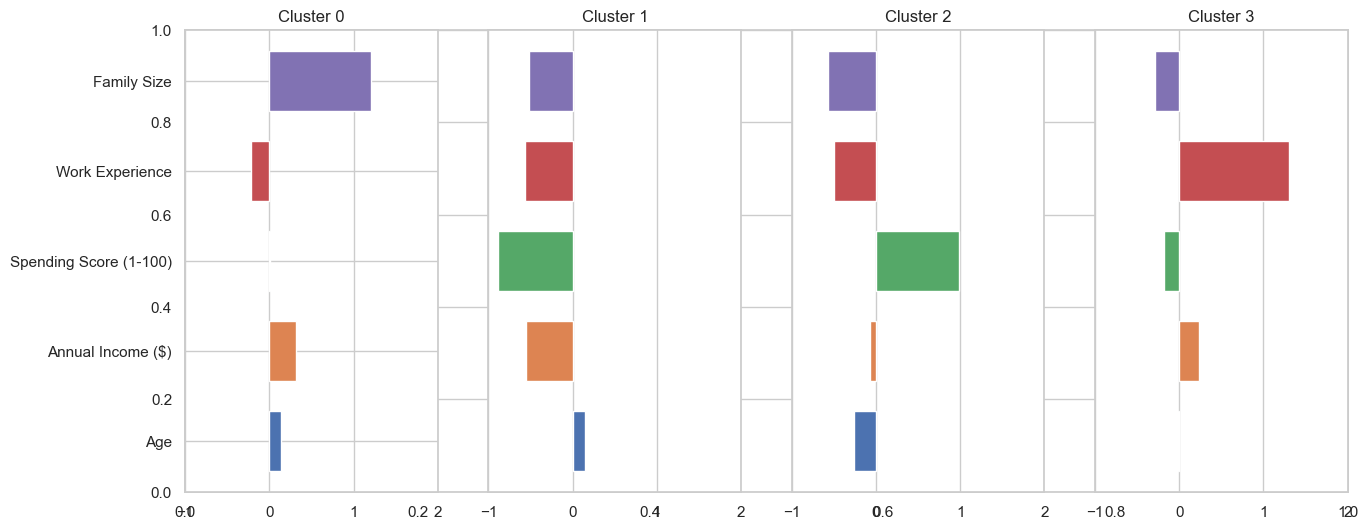

In [16]:
fig = km.plot_barras_centros(figsize=(15, 6))
plt.show()

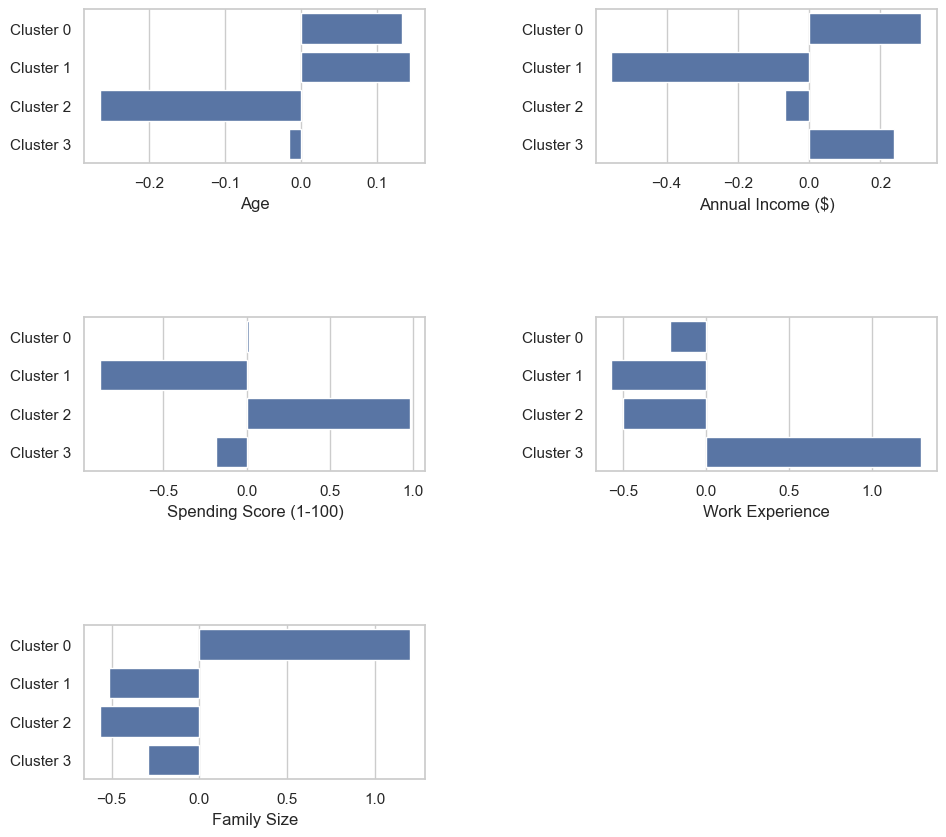

In [17]:
fig = km.plot_detalle_centros(figsize=(11, 10), dpi=100)
plt.show()

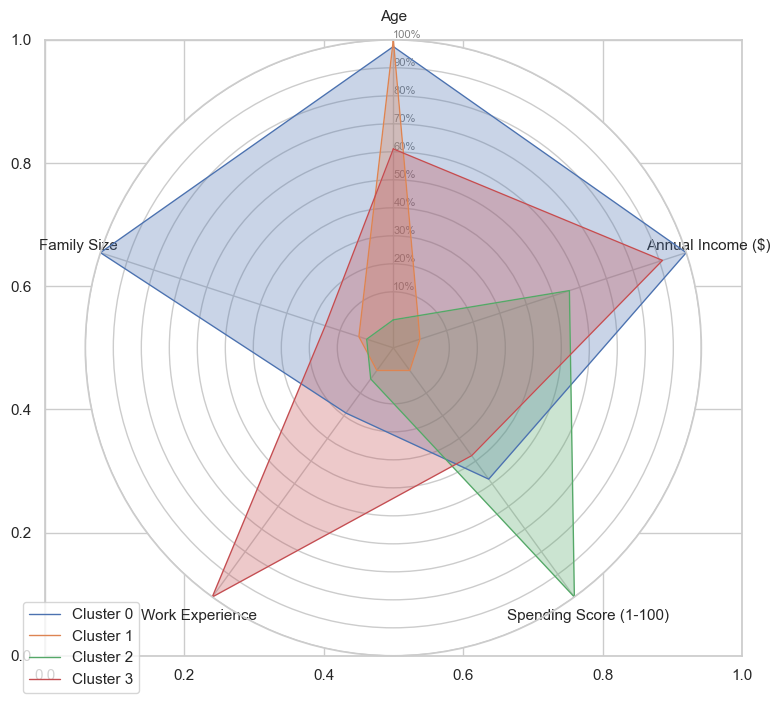

In [18]:
fig = km.plot_radar_centros(figsize=(9, 8))
plt.show()

In [19]:
perfil_km = km.tabla_perfiles(datos_originales=df[variables])
perfil_km

,n,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
cluster,,,,,,
0,551,53.27,125204.66,51.29,3.24,6.14
1,462,53.55,85554.93,26.35,1.86,2.76
2,499,42.16,107807.50,78.34,2.14,2.65
3,488,49.11,121668.16,45.90,9.21,3.19


**Perfil de los cuatro segmentos de K-Means:**
Leyendo los centroides estandarizados junto con la tabla en escala original, cada grupo queda definido
por una sola variable dominante, lo que refuerza que se trata de cortes sobre un continuo. El cluster 0
(551 clientes) son las familias grandes: `Family Size` en +1,20 z (6,14 personas frente a 3,77 del
total), el mayor ingreso (unos 125 200 USD) y edad alta (53,3 años), con gasto exactamente medio. El
cluster 1 (462 clientes) es el de bajo gasto, único con `Spending Score` muy negativo (−0,88 z, puntaje
26,4), menor ingreso (unos 85 600 USD) y familias pequeñas. El cluster 2 (499 clientes) es el de alto
gasto (+0,98 z, puntaje 78,3), el más joven (42,2 años) y con ingreso intermedio. El cluster 3
(488 clientes) son los profesionales veteranos, con `Work Experience` en +1,30 z (9,21 años frente a
4,10 del total) e ingreso alto pero gasto por debajo de la media.

El radar y el gráfico de detalle dejan ver el patrón con claridad: cada polígono se estira hacia un eje
distinto y ningún cluster destaca en dos variables a la vez. Los cuatro segmentos son de tamaño muy
parecido (462–551), otro síntoma de partición geométrica de un espacio uniforme más que de grupos
naturales de distinto tamaño. Lo más relevante para el negocio es que `Spending Score` y
`Annual Income ($)` no se alinean: el grupo que más gasta tiene ingreso intermedio mientras que el de
mayor ingreso gasta justo la media, de modo que la propensión al gasto no está explicada por el ingreso.

In [20]:
componentes = km.aplicar_pca(n_components=2)
print("Varianza explicada por componente (%):", np.round(km.pca.explained_variance_ratio_ * 100, 1))
print("Varianza acumulada (%):", round(km.pca.explained_variance_ratio_.sum() * 100, 1))

Componentes
 [[-1.93832583  0.15375754]
 [-1.71187673 -1.01340726]
 [-1.69071798  0.35678232]
 ...
 [ 0.11211382  1.41969903]
 [ 1.15085277  1.08524838]
 [-0.06171743  0.81360503]]
Varianza explicada por componente (%): [22.8 20.8]
Varianza acumulada (%): 43.6


In [21]:
cargas = pd.DataFrame(km.pca.components_.T, index=variables, columns=["PC1", "PC2"])
cargas.round(2)

,PC1,PC2
Age,0.23,0.70
Annual Income ($),0.67,-0.21
Spending Score (1-100),-0.02,-0.62
Work Experience,0.45,-0.24
Family Size,0.55,0.14


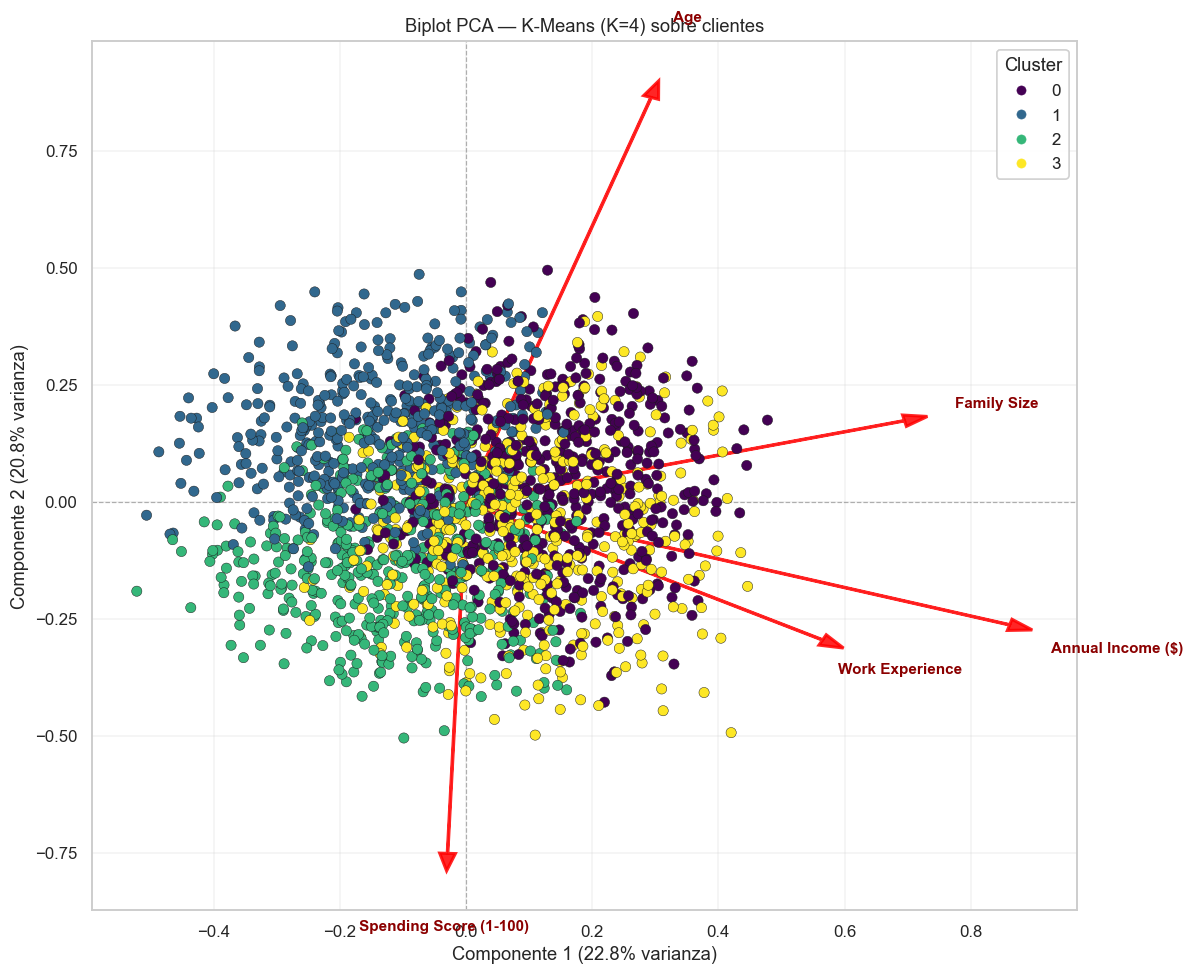

In [22]:
fig = km.plot_biplot(anotar=False, titulo=f"Biplot PCA — K-Means (K={K}) sobre clientes")
plt.show()

**Proyección PCA del K-Means:**
El PCA a dos componentes solo retiene el 43,6 % de la varianza (22,8 % + 20,8 %), porque las cinco
variables están casi incorreladas y no hay una dirección dominante que resuma a las demás. Eso implica
que el gráfico 2D no puede mostrar fielmente la separación de los grupos: queda un 56 % de la
información repartida en las otras tres dimensiones. Con esa reserva, la tabla de cargas es informativa.
El PC1 se construye sobre `Annual Income ($)`, `Family Size` y `Work Experience`, un eje de posición
socioeconómica y carga familiar, mientras que el PC2 contrapone `Age` contra `Spending Score` y separa a
los clientes jóvenes que gastan mucho de los mayores que gastan poco. Las nubes de colores se distinguen
pero se tocan en las fronteras, sin espacios vacíos entre ellas: es la representación visual de una
silueta de 0,148, donde los límites entre segmentos son cortes geométricos dentro de una nube continua.

### Clustering jerárquico aglomerativo

In [23]:
cj = ClusteringJerarquico(X_scaled)
dist = cj.matriz_distancias(metric="euclidean")
print("Número de pares de distancias:", dist.shape[0])
print("Distancia mínima: %.3f | media: %.3f | máxima: %.3f" % (dist.min(), dist.mean(), dist.max()))

(2000, 5)
Número de pares de distancias: 1999000
Distancia mínima: 0.055 | media: 3.037 | máxima: 6.982


In [24]:
ward_res, average_res, single_res, complete_res = cj.calcular_agregaciones()
print("Matriz de enlaces de Ward (últimas 5 fusiones):")
print(np.round(ward_res[-5:], 2))

Matriz de enlaces de Ward (últimas 5 fusiones):
[[3990.   3992.     30.83  640.  ]
 [3986.   3987.     32.43  508.  ]
 [3989.   3995.     37.67  851.  ]
 [3993.   3996.     40.25 1360.  ]
 [3994.   3997.     48.29 2000.  ]]


**Matriz de distancias y de enlaces:**
Con 2 000 clientes se calculan 1 999 000 distancias por pares. La distancia euclídea media es de 3,04 en
el espacio estandarizado de cinco dimensiones, con un rango de 0,055 a 6,98; que la media esté cerca del
centro del rango y no exista un pico de distancias pequeñas es, otra vez, la firma de una nube homogénea
sin núcleos densos. La matriz de enlaces de Ward indica en cada fila qué dos clusters se unen, a qué
altura y cuántos elementos tiene el grupo resultante: las últimas fusiones ocurren a alturas de 30,8,
32,4, 37,7, 40,3 y 48,3, uniendo bloques ya muy poblados hasta llegar a los 2 000 clientes.

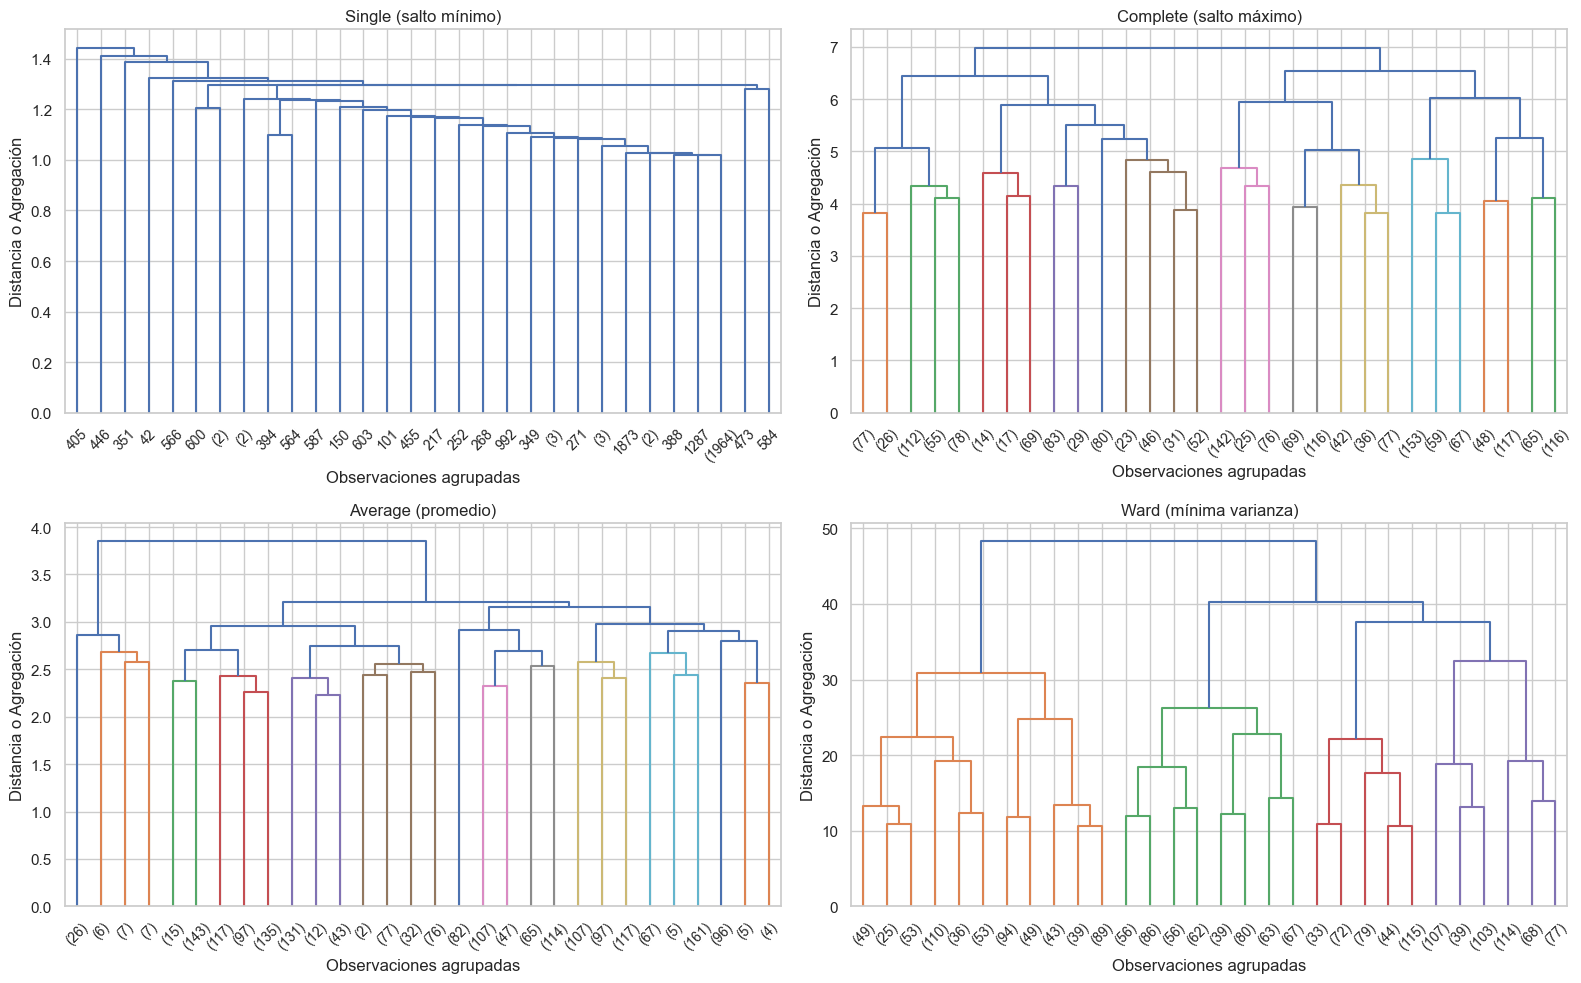

In [25]:
fig = cj.plot_dendrogramas_comparacion(figsize=(16, 10), truncate=30)
plt.show()

In [26]:
cj.correlacion_cophenetica()

,metodo,cophenetica
2,average,0.459
3,ward,0.385
1,complete,0.381
0,single,0.351


**Comparación de los métodos de vinculación:**
Los cuatro dendrogramas se truncan a los 30 nodos superiores, porque con 2 000 hojas serían ilegibles.
Single produce el clásico efecto cadena, pegando observaciones una a una a un mismo bloque con alturas
de fusión mínimas, y es el peor de los cuatro (cofenética de 0,351). Complete genera clusters más
compactos pero un árbol muy desbalanceado (0,381). Average es el de mejor correlación cofenética
(0,459), es decir el que preserva mejor las distancias originales, pero produce un grupo dominante y
varios muy pequeños, poco útil para segmentar. Ward se queda en 0,385 y en cambio produce bloques de
tamaño comparable y bien definidos, que es lo que se necesita para una segmentación accionable.

Ninguna correlación cofenética llega a 0,5, lo que confirma desde otro ángulo lo que ya dijo la silueta:
ningún árbol jerárquico representa bien esta nube de datos, porque la nube no tiene estructura
jerárquica real. Se usa Ward por el criterio de utilidad para el negocio, asumiendo el compromiso de
0,074 puntos de cofenética frente a average.

In [27]:
# Alturas de corte del dendrograma de Ward: al cortar en una altura h, el número de
# clusters es 1 + (número de fusiones que ocurren por encima de h)
alturas_ward = np.sort(ward_res[:, 2])
print("Últimas 12 alturas de fusión (Ward):", np.round(alturas_ward[-12:], 2))

cortes = {}
for k in [2, 3, 4, 6]:
    # punto medio entre las dos fusiones que delimitan el corte para k clusters
    superior = alturas_ward[-(k - 1)]
    inferior = alturas_ward[-k]
    cortes[k] = round((superior + inferior) / 2, 1)
print("\nAlturas de corte para cada k:", cortes)

Últimas 12 alturas de fusión (Ward): [19.21 19.23 22.2  22.4  22.78 24.76 26.27 30.83 32.43 37.67 40.25 48.29]

Alturas de corte para cada k: {2: np.float64(44.3), 3: np.float64(39.0), 4: np.float64(35.1), 6: np.float64(28.5)}


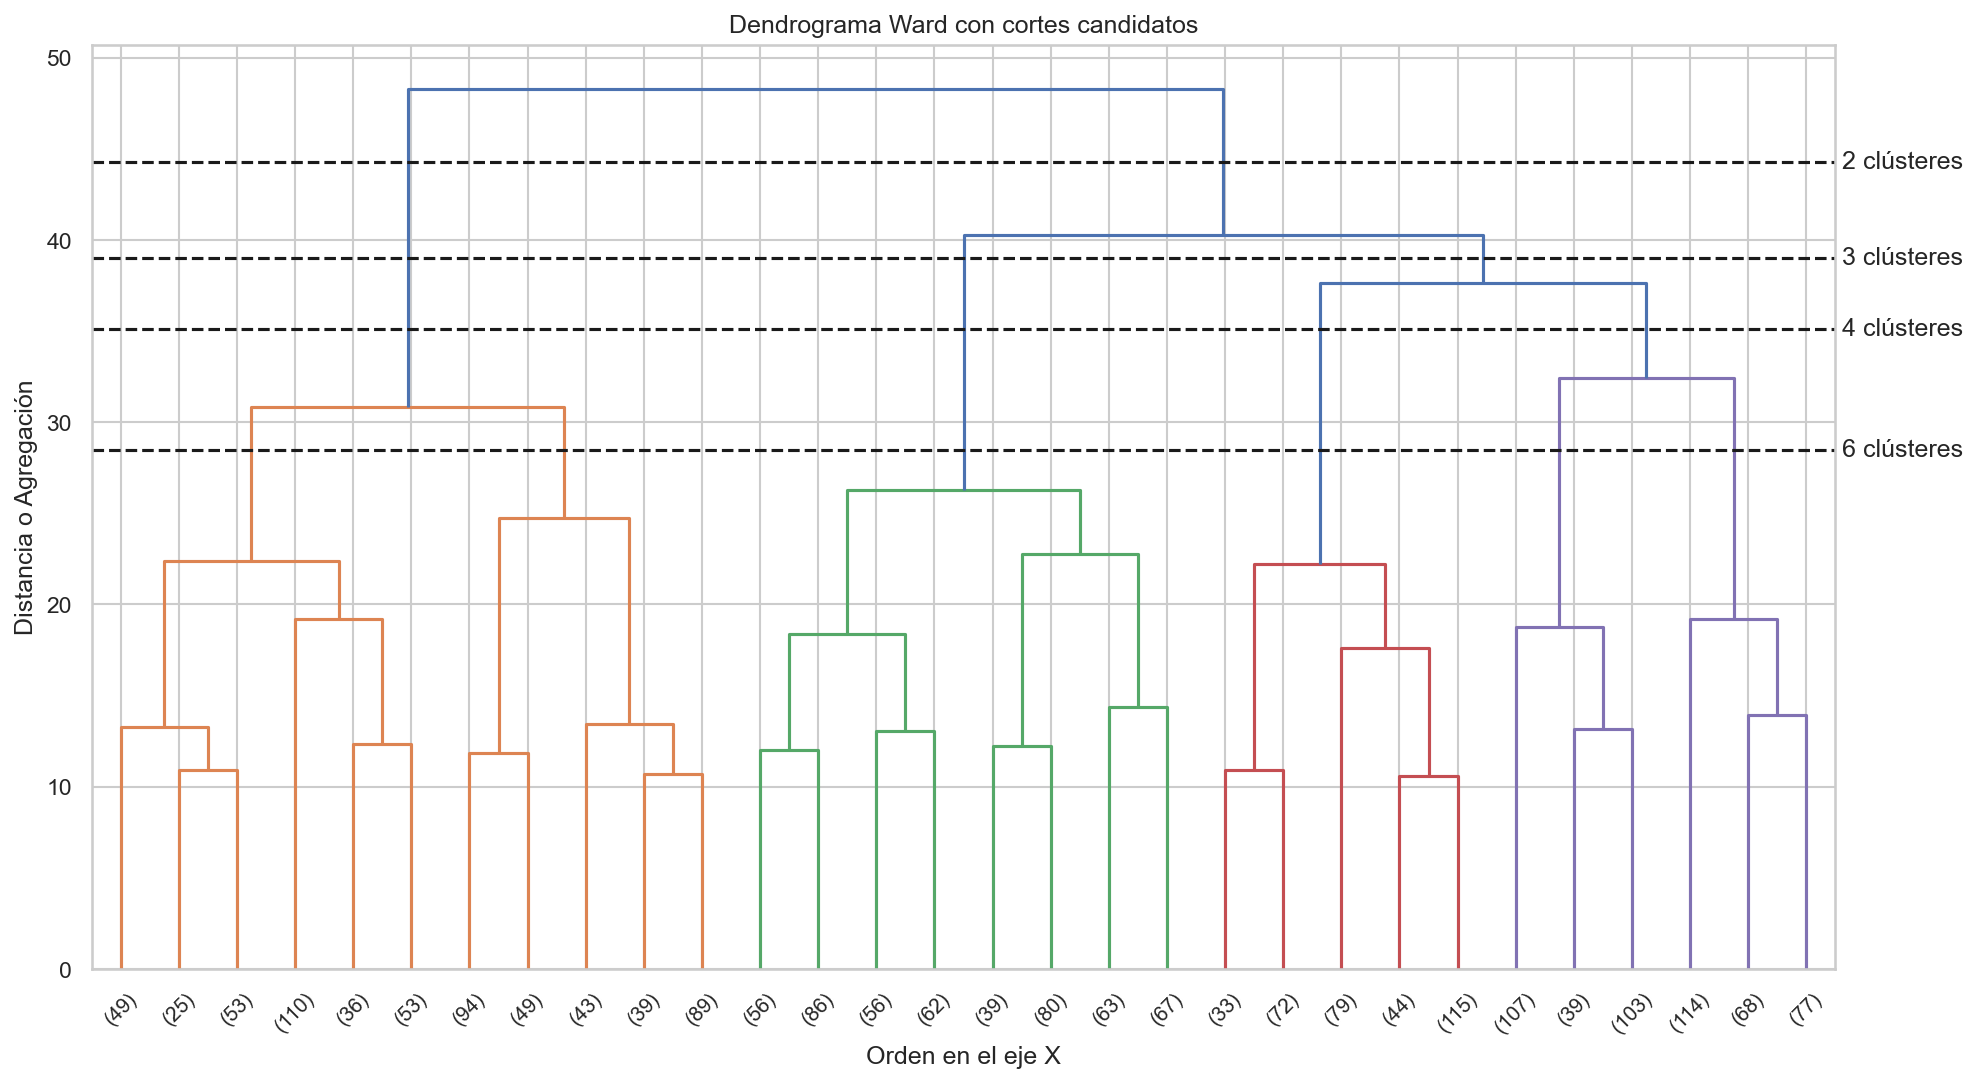

In [28]:
fig = cj.plot_dendrograma_corte(
    alturas=list(cortes.values()),
    etiquetas=[f"{k} clústeres" for k in cortes],
    figsize=(15, 8),
    truncate=30,
)
plt.show()

**Corte del dendrograma de Ward:**
Cada línea horizontal corta un número distinto de ramas verticales, y ese número es el número de
clusters. Las alturas se calcularon programáticamente como el punto medio entre las dos fusiones que
delimitan cada corte, para no depender de una lectura visual aproximada: 44,3 para dos clusters, 39,0
para tres, 35,1 para cuatro y 28,5 para seis. La regla práctica es cortar donde haya un salto vertical
grande entre fusiones consecutivas, y mirando las últimas alturas de Ward (26,27 · 30,83 · 32,43 ·
37,67 · 40,25 · 48,29) los dos saltos mayores son el de 40,25 a 48,29, de 8,04, que corresponde al corte
en dos clusters, y el de 32,43 a 37,67, de 5,24, que corresponde al corte en cuatro. El segundo salto más
grande del árbol coincide precisamente con k = 4, el mismo valor que indicó el codo de Jambú, de modo que
el dendrograma valida la elección de K de forma independiente. Se corta en k = 4 y así ambos algoritmos
quedan comparables con el mismo número de grupos.

In [29]:
grupos_cj = cj.obtener_grupos(k=K, method="ward", metric="euclidean")
print("Etiquetas de los primeros 40 clientes:")
print(grupos_cj[:40])
print("\nTamaño de cada cluster:")
print(pd.Series(grupos_cj).value_counts().sort_index())

Etiquetas de los primeros 40 clientes:
[3 3 3 3 2 3 3 3 3 1 3 3 2 3 3 3 0 2 3 3 0 3 0 3 3 3 0 3 3 3 3 3 3 3 3 3 0
 1 0 3]

Tamaño de cada cluster:
0    640
1    509
2    343
3    508
Name: count, dtype: int64


In [30]:
centros_cj = cj.calcular_centros(k=K)
pd.DataFrame(centros_cj, columns=variables).round(2).rename_axis("cluster")

,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
cluster,,,,,
0,0.04,0.12,-0.24,1.07,0.16
1,0.31,0.26,0.99,-0.36,-0.11
2,0.03,-0.03,-0.63,-0.71,0.97
3,-0.38,-0.39,-0.26,-0.50,-0.75


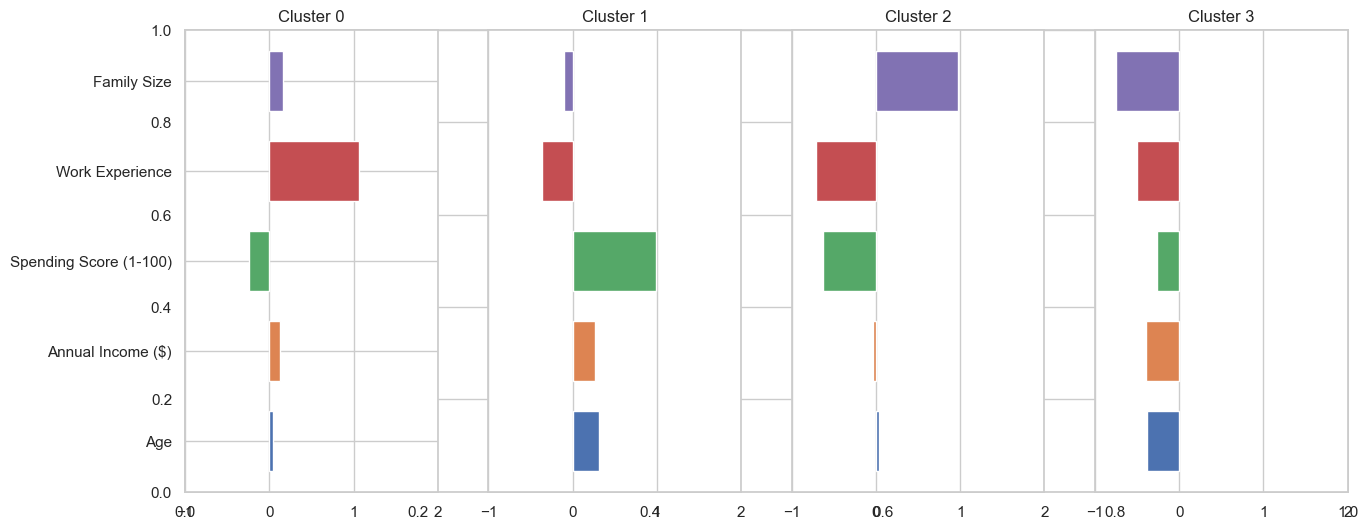

In [31]:
fig = cj.plot_barras_centros(figsize=(15, 6))
plt.show()

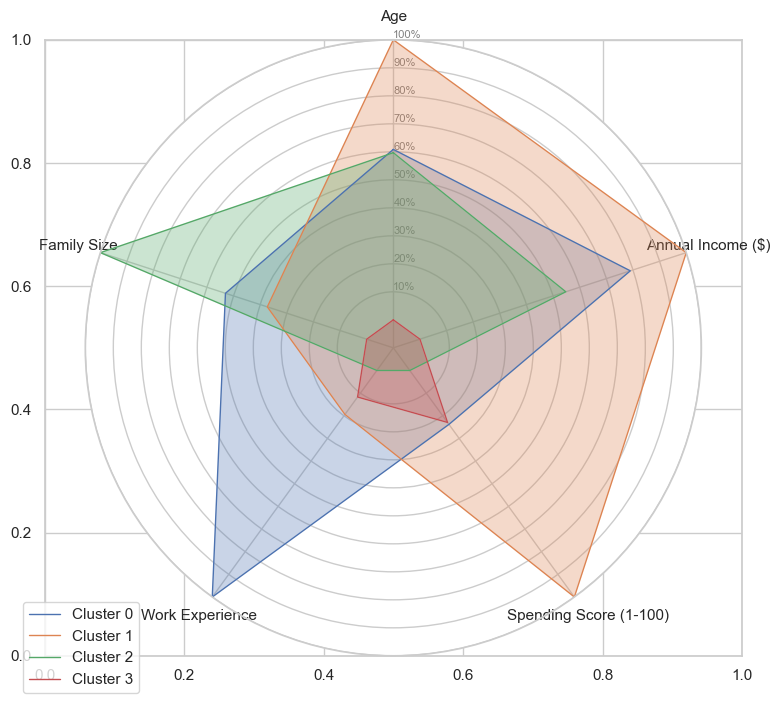

In [32]:
fig = cj.plot_radar_centros(figsize=(9, 8))
plt.show()

In [33]:
perfil_cj = cj.tabla_perfiles(datos_originales=df[variables])
perfil_cj

,n,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
cluster,,,,,,
0,640,50.65,116445.17,44.13,8.28,4.09
1,509,58.19,122684.10,78.64,2.68,3.55
2,343,50.42,109254.83,33.35,1.33,5.69
3,508,38.92,92989.42,43.74,2.14,2.28


**Perfil de los clusters jerárquicos (Ward, k = 4):**
Ward produce grupos más desiguales que K-Means (640 / 509 / 343 / 508 frente a 462–551) y con perfiles
que no coinciden. Su cluster 0, el más numeroso con 640 clientes, se define por `Work Experience` en
+1,07 z (8,28 años) y gasto por debajo de la media. El cluster 1 (509 clientes) es el de mayor gasto
(78,6) pero también el de mayor edad (58,2 años) e ingreso más alto. El cluster 2 (343 clientes) reúne
familias grandes (5,69 miembros) con el gasto más bajo (33,4) y prácticamente sin experiencia laboral.
El cluster 3 (508 clientes) es el más joven (38,9 años), de menor ingreso y familias pequeñas.

La diferencia frente a K-Means es sustantiva porque el eje de la edad pesa mucho más en Ward: el
segmento de alto gasto que K-Means retrata como joven (42,2 años) Ward lo retrata como mayor
(58,2 años), y las familias grandes, que en K-Means son el grupo de mayor ingreso y gasto medio, en Ward
son el de menor gasto. Los dos algoritmos están contando historias distintas sobre los mismos datos,
algo que solo puede ocurrir cuando no hay grupos naturales que ambos tendrían que encontrar por igual.

---
## e) Análisis y conclusiones visuales

In [34]:
tabla_cruzada = pd.crosstab(
    pd.Series(etiquetas_km, name="K-Means"),
    pd.Series(grupos_cj, name="Ward (jerárquico)"),
)
tabla_cruzada

Ward (jerárquico),0,1,2,3
K-Means,,,,
0,175,130,232,14
1,82,33,91,256
2,9,290,12,188
3,374,56,8,50


In [35]:
ari = adjusted_rand_score(grupos_cj, etiquetas_km)
sil_km = silhouette_score(X, etiquetas_km)
sil_cj = silhouette_score(X, grupos_cj)

pd.DataFrame({
    "métrica": ["Silueta media", "Nº de clusters", "Cluster más pequeño", "Cluster más grande"],
    "K-Means": [round(sil_km, 4), K, int(np.bincount(etiquetas_km).min()), int(np.bincount(etiquetas_km).max())],
    "Ward": [round(sil_cj, 4), K, int(np.bincount(grupos_cj).min()), int(np.bincount(grupos_cj).max())],
})

,métrica,K-Means,Ward
0,Silueta media,0.1477,0.094
1,Nº de clusters,4.0000,4.000
2,Cluster más pequeño,462.0000,343.000
3,Cluster más grande,551.0000,640.000


In [36]:
print(f"Índice de Rand ajustado (ARI) entre K-Means y Ward: {ari:.3f}")

Índice de Rand ajustado (ARI) entre K-Means y Ward: 0.243


**Grado de acuerdo entre los algoritmos:**
El ARI es de 0,243: en una escala donde 1 es coincidencia perfecta y 0 el acuerdo esperado por puro
azar, significa que los dos algoritmos concuerdan poco. La tabla cruzada lo detalla. La única
correspondencia razonable es la del cluster 3 de K-Means, el de profesionales veteranos, con el
cluster 0 de Ward, donde coinciden 374 de 488 clientes (77 %); en cambio el cluster de alto gasto de
K-Means se reparte entre dos grupos de Ward (290 y 188), el de familias grandes se dispersa en tres
(175 / 130 / 232) y el de bajo gasto en otros tres (82 / 91 / 256). En cuanto a la calidad, K-Means gana
en silueta (0,1477 frente a 0,0940 de Ward) y produce grupos más equilibrados, lo cual es esperable
porque optimiza directamente la compacidad intra-cluster, que es lo que mide la silueta, mientras que
Ward construye el árbol mediante fusiones sucesivas irreversibles. Ambos valores son bajísimos, así que
la lectura correcta no es que K-Means sea mejor que Ward, sino que es menos malo en unos datos donde no
hay clusters que encontrar.

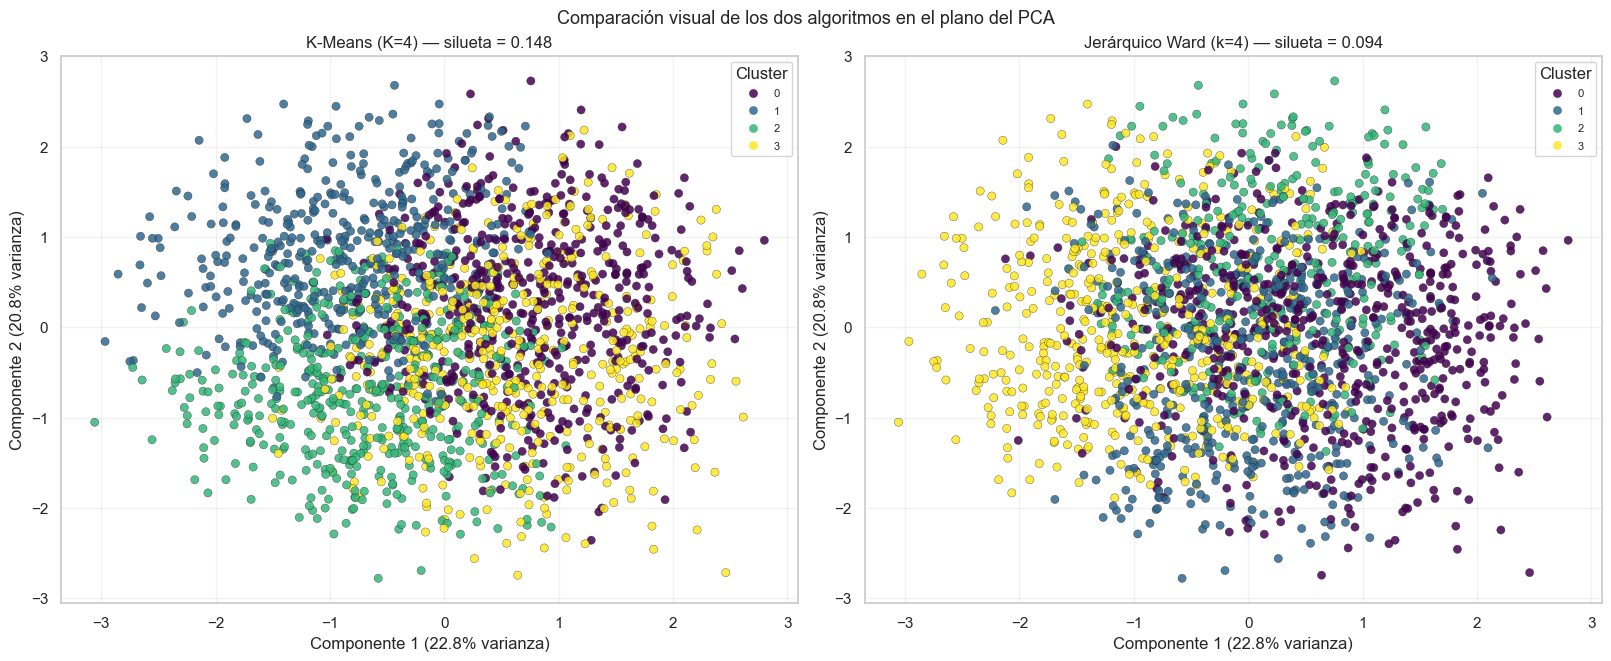

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)
var_exp = km.pca.explained_variance_ratio_ * 100

for ax, (labels, titulo, sil) in zip(
    axes,
    [(etiquetas_km, f"K-Means (K={K})", sil_km), (grupos_cj, f"Jerárquico Ward (k={K})", sil_cj)],
):
    sc = ax.scatter(componentes[:, 0], componentes[:, 1], c=labels, cmap="viridis",
                    s=35, edgecolor="k", linewidth=0.25, alpha=0.85)
    ax.set_xlabel(f"Componente 1 ({var_exp[0]:.1f}% varianza)")
    ax.set_ylabel(f"Componente 2 ({var_exp[1]:.1f}% varianza)")
    ax.set_title(f"{titulo} — silueta = {sil:.3f}")
    ax.legend(*sc.legend_elements(), title="Cluster", loc="best", fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle("Comparación visual de los dos algoritmos en el plano del PCA", fontsize=13)
plt.show()

**Comparación visual en el plano del PCA:**
Los dos paneles confirman lo que dijeron las métricas. K-Means divide el plano en regiones con fronteras
rectas y nítidas, la geometría propia de un algoritmo que asigna cada punto al centroide más cercano;
Ward produce regiones de formas más irregulares, con mayor solapamiento visual y un grupo claramente más
grande que los demás. En ninguno de los dos paneles se ven huecos entre grupos: en un dataset con
clusters reales esperaríamos islas separadas por zonas vacías, y aquí lo que hay es una nube continua
cortada en pedazos de dos formas distintas. Conviene recordar además que este plano solo representa el
43,6 % de la varianza, por lo que parte del solapamiento visual es un artefacto de la proyección y no
separación real perdida.

**Conclusión:**
El preprocesamiento fue indispensable: los 26 nulos codificados como cero en `Age` y `Annual Income ($)`,
sin tratar, habrían generado observaciones artificialmente lejanas del resto y habrían contaminado los
centroides, y se distinguieron correctamente de los 431 ceros legítimos de `Work Experience`. La
estandarización fue decisiva, porque sin ella el ingreso —con un rango de unos 190 000— habría anulado
por completo el aporte de `Family Size` al cálculo de distancias. El codo de Jambú fijó K = 4 y el
dendrograma de Ward validó ese mismo valor de forma independiente.

El resultado central, sin embargo, es que este dataset no tiene estructura de clusters, y tres
evidencias independientes lo confirman: la silueta nunca supera 0,167 y crece con k en lugar de tener un
pico interior, ninguna correlación cofenética alcanza 0,5, y el ARI entre los dos algoritmos es de solo
0,243. Los cuatro segmentos obtenidos son una partición útil impuesta sobre un continuo, no grupos
naturales descubiertos: es un resultado legítimo y hay que reportarlo como tal, porque presentarlos como
"los grupos que existen en la base de clientes" sería incorrecto. La causa más probable es que
`Customers.csv` sea un dataset sintético con variables generadas de forma independiente y casi uniforme,
lo que explica que no haya atípicos y que el PCA no logre concentrar varianza.

Con esa reserva, el hallazgo accionable es que el gasto no sigue al ingreso: el segmento de mayor gasto
tiene ingreso intermedio y el de mayor ingreso gasta exactamente la media, de modo que segmentar
campañas por poder adquisitivo sería un error en esta base de clientes. Antes de apoyar una estrategia
comercial en esta segmentación convendría enriquecer el dataset con variables transaccionales reales
—frecuencia de visita, ticket promedio, categorías compradas—, porque con las cinco variables actuales no
hay señal suficiente para segmentar.